## Household input data

Input data from the survey or generated to assign the household variables and parameters in the model.

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import MinMaxScaler
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
data_UK = pd.read_csv('../../data/raw/SCALAR_Coastal_Study_new_respondents_Wave_Five_UK.csv')

In [3]:
data_UK.head()

,ID,Q0_place_UK,Q1_home_NL_UK,Q4_home_size_UK,Q5_home_tenure,Q5b_home_sell,Q6_home_costs,Q7_move_in,Q8_move_out,Q12_neighborhood_trust,Q13_neighborhood_community,Q14_neighborhood_pleasure,Q15_neighborhood_favorite,Q16_neighborhood_identity,Q11_search_improve,Q11_search_social,Q11_search_family,Q11_search_area,Q11_search_job,Q11_search_location,Q11_search_hazard,Q11_search_other,Q11_search_dont_know,Q11a_hazard_type1,Q11a_hazard_type3,Q11a_hazard_type4,Q11a_hazard_type5,Q11a_hazard_type10,Q11a_hazard_type6,Q11a_hazard_type9,Q11a_hazard_not_say,R02_perc_prob,R02_perc_prob_other_text,Q18_flood_exp,Q18a_flood_where,Q18b_flood_year,Q18d_flood_cost,R03_perc_damage_UK1,R03_perc_damage_UK2,R03_perc_damage_UK3,R05_worry,R01_resilience_5,R01_resilience_6,Q17_compens_noone,Q17_compens_ins,Q17_compens_owner,Q17_compens_family,Q17_compens_ngo,Q17_compens_other,Q17_compens_dont_know,R1a_self_efficacy_SM1,R1a_self_efficacy_SM2,R1a_self_efficacy_SM3,R1a_self_efficacy_SM4,R1a_self_efficacy_SM5,R1a_self_efficacy_SM6,R1a_self_efficacy_SM7,R1a_self_efficacy_SM8,R1b_resp_efficacy_SM1,R1b_resp_efficacy_SM2,R1b_resp_efficacy_SM3,R1b_resp_efficacy_SM4,R1b_resp_efficacy_SM5,R1b_resp_efficacy_SM6,R1b_resp_efficacy_SM7,R1b_resp_efficacy_SM8,R1c_perc_cost_SM1,R1c_perc_cost_SM2,R1c_perc_cost_SM3,R1c_perc_cost_SM4,R1c_perc_cost_SM5,R1c_perc_cost_SM6,R1c_perc_cost_SM7,R1c_perc_cost_SM8,R2_implementation_SM1,R2_implementation_SM2,R2_implementation_SM3,R2_implementation_SM4,R2_implementation_SM5,R2_implementation_SM6,R2_implementation_SM7,R2_implementation_SM8,R1a_self_efficacy_NM1,R1a_self_efficacy_NM2,R1a_self_efficacy_NM3,R1a_self_efficacy_NM4,R1a_self_efficacy_NM5,R1a_self_efficacy_NM6,R1a_self_efficacy_NM7,R1a_self_efficacy_NM8,R1a_self_efficacy_NM9,R1a_self_efficacy_NM10,R1a_self_efficacy_NM11,R1b_resp_efficacy_NM1,R1b_resp_efficacy_NM2,R1b_resp_efficacy_NM3,R1b_resp_efficacy_NM4,R1b_resp_efficacy_NM5,R1b_resp_efficacy_NM6,R1b_resp_efficacy_NM7,R1b_resp_efficacy_NM8,R1b_resp_efficacy_NM9,R1b_resp_efficacy_NM10,R1b_resp_efficacy_NM11,R1c_perc_cost_NM1,R1c_perc_cost_NM2,R1c_perc_cost_NM3,R1c_perc_cost_NM4,R1c_perc_cost_NM5,R1c_perc_cost_NM6,R1c_perc_cost_NM7,R1c_perc_cost_NM8,R1c_perc_cost_NM9,R1c_perc_cost_NM10,R1c_perc_cost_NM11,R2_implementation_NM1,R2_implementation_NM2,R2_implementation_NM3,R2_implementation_NM4,R2_implementation_NM5,R2_implementation_NM6,R2_implementation_NM7,R2_implementation_NM8,R2_implementation_NM9,R2_implementation_NM10,R2_implementation_NM11,Q41_ins_UK,Q41a_property_UK,Q41a_possessions_UK,Q41b_ins_intention_UK,Q41c_ins_self_efficacy_UK,Q25_fl_convo_times,Q25a_fl_convo_local,Q26_measures_advice,Q27_fl_convo_people,Q28_convo_resp_efficacy,Q28_convo_costs,Q28_convo_prob,Q28_convo_severity,Q28_convo_worry,Q28_convo_community,Q28_convo_gov,Q29a_adapt_p1,Q29a_adapt_p2,Q29a_adapt_p3,Q29d_distance_p1,Q29d_distance_p2,Q29d_distance_p3,Q29f_com_freq_p1,Q29f_com_freq_p2,Q29f_com_freq_p3,Q29g_flood_com_freq_p1,Q29g_flood_com_freq_p2,Q29g_flood_com_freq_p3,Q29i_worry_p1,Q29i_worry_p2,Q29i_worry_p3,Q29j_valuable_exp_p1,Q29j_valuable_exp_p2,Q29j_valuable_exp_p3,Q30_adapt_against,Q31_give_advice,Q32_influence,Q33_ask_advice_family,Q33_ask_advice_neighbor,Q33_ask_advice_colleague,Q33_ask_advice_online,Q33_ask_advice_expert,Q33_ask_advice_teacher,Q33_ask_advice_ngo,Q33_ask_advice_gov,Q33_ask_advice_other,Q33_ask_advice_dont_know,Q33_ask_advice_never,Q33_ask_advice_other_text,Q34_influential_family,Q34_influential_neighbor,Q34_influential_colleague,Q34_influential_online,Q34_influential_expert,Q34_influential_teacher,Q34_influential_ngo,Q34_influential_gov,Q34_influential_other,Q34_influential_dont_know,Q34_influential_noone,Q34_influential_other_text,Q16_compens_gov,Q37_govern,Q38_market,Q39_technology,Q40_nature,Q41a_media_freq,Q41b_s_media_freq,Q42_local_gov_info,Q42a_local_gov_trust,Q42b_local_gov_act,Q43_national_gov_info,Q43a_national_gov_trust,Q43b_national_gov_act,Q44_trust_pm,Q44_trust_gov_rep,Q44_trust_family,Q44_trust_media,Q44_trust_

In [4]:
print(data_UK.columns.tolist())

['ID', 'Q0_place_UK', 'Q1_home_NL_UK', 'Q4_home_size_UK', 'Q5_home_tenure', 'Q5b_home_sell', 'Q6_home_costs', 'Q7_move_in', 'Q8_move_out', 'Q12_neighborhood_trust', 'Q13_neighborhood_community', 'Q14_neighborhood_pleasure', 'Q15_neighborhood_favorite', 'Q16_neighborhood_identity', 'Q11_search_improve', 'Q11_search_social', 'Q11_search_family', 'Q11_search_area', 'Q11_search_job', 'Q11_search_location', 'Q11_search_hazard', 'Q11_search_other', 'Q11_search_dont_know', 'Q11a_hazard_type1', 'Q11a_hazard_type3', 'Q11a_hazard_type4', 'Q11a_hazard_type5', 'Q11a_hazard_type10', 'Q11a_hazard_type6', 'Q11a_hazard_type9', 'Q11a_hazard_not_say', 'R02_perc_prob', 'R02_perc_prob_other_text', 'Q18_flood_exp', 'Q18a_flood_where', 'Q18b_flood_year', 'Q18d_flood_cost', 'R03_perc_damage_UK1', 'R03_perc_damage_UK2', 'R03_perc_damage_UK3', 'R05_worry', 'R01_resilience_5', 'R01_resilience_6', 'Q17_compens_noone', 'Q17_compens_ins', 'Q17_compens_owner', 'Q17_compens_family', 'Q17_compens_ngo', 'Q17_compens_o

For the households we need the following data:

*PMT-related variables*
- threat appraisal:
    * perceived probability (R02_perc_prob)
    * perceived damage / severity (R03_perc_damage)
    * worry (R05_worry)
- coping appraisal
    * perceived cost (R1c_perc_costs)
    * perceived response efficacy (R1b_resp_efficacy)
    * self-efficacy (R1a_self_efficacy)
    * each for the following measures
       * dry-proofing:
          * installing anti-backflow valves on pipes (SM5)
          * installing a pump or similar to drain water (SM6)
          * fixing water barriers (SM7)
       * wet-proofing:
          * strengthening house foundations (SM2)
          * reinforcing walls (SM3)
          * raising electricity meter (SM4)
- other:
    * flood experience
    * weight social norm vs PMT (Q30_adapt_against)
 
*Socio-demographics*
- Age (Q0_age)
- Level of education (Q0_education_UK)
- level of income (Q53_income_UK)
- amount of savings (Q58_savings)
- Home size (Q4_home_size_UK)

In [5]:
relevant_columns = ['R02_perc_prob', 'R05_worry', 'R03_perc_damage_UK1', 'R03_perc_damage_UK2', 'R03_perc_damage_UK3',# threat appraisal
                    'R1a_self_efficacy_SM2', 'R1b_resp_efficacy_SM2', 'R1c_perc_cost_SM2', # coping appraisal
                    'R1a_self_efficacy_SM3', 'R1b_resp_efficacy_SM3', 'R1c_perc_cost_SM3', 
                    'R1a_self_efficacy_SM4', 'R1b_resp_efficacy_SM4', 'R1c_perc_cost_SM4', 
                    'R1a_self_efficacy_SM5', 'R1b_resp_efficacy_SM5', 'R1c_perc_cost_SM5', 
                    'R1a_self_efficacy_SM6', 'R1b_resp_efficacy_SM6', 'R1c_perc_cost_SM6', 
                    'R1a_self_efficacy_SM7', 'R1b_resp_efficacy_SM7', 'R1c_perc_cost_SM7', 
                    'Q18_flood_exp', 'Q30_adapt_against',
                    'R2_implementation_SM2', 'R2_implementation_SM3', 'R2_implementation_SM4', 'R2_implementation_SM5', 'R2_implementation_SM6', 'R2_implementation_SM7', 
                    'Q0_age', 'Q0_education_UK', 'Q53_income_UK', 'Q58_savings', 'Q4_home_size_UK']

In [6]:
data_households = data_UK[relevant_columns]
data_households.head()

,R02_perc_prob,R05_worry,R03_perc_damage_UK1,R03_perc_damage_UK2,R03_perc_damage_UK3,R1a_self_efficacy_SM2,R1b_resp_efficacy_SM2,R1c_perc_cost_SM2,R1a_self_efficacy_SM3,R1b_resp_efficacy_SM3,R1c_perc_cost_SM3,R1a_self_efficacy_SM4,R1b_resp_efficacy_SM4,R1c_perc_cost_SM4,R1a_self_efficacy_SM5,R1b_resp_efficacy_SM5,R1c_perc_cost_SM5,R1a_self_efficacy_SM6,R1b_resp_efficacy_SM6,R1c_perc_cost_SM6,R1a_self_efficacy_SM7,R1b_resp_efficacy_SM7,R1c_perc_cost_SM7,Q18_flood_exp,Q30_adapt_against,R2_implementation_SM2,R2_implementation_SM3,R2_implementation_SM4,R2_implementation_SM5,R2_implementation_SM6,R2_implementation_SM7,Q0_age,Q0_education_UK,Q53_income_UK,Q58_savings,Q4_home_size_UK
0,6,1,,98,,1,1,5,1,1,5,5,1,2,4,1,2,2,1,3,3,2,3,0,3,4,4,4,4,4,4,62,11,2,7,2
1,2,1,,1,,1,1,5,5,1,5,1,1,3,3,1,2,3,3,3,4,3,2,0,1,4,4,4,4,4,4,57,18,1,98,2
2,1,1,,1,,1,5,5,5,5,5,5,4,1,5,5,1,5,4,1,1,4,3,0,5,4,4,4,4,4,4,65,9,4,98,5
3,1,1,,1,,1,5,5,1,5,5,1,5,5,1,5,5,1,5,5,1,5,5,0,1,4,4,4,4,4,4,35,1,5,7,6
4,2,1,,1,,2,2,5,2,2,5,2,2,5,2,2,5,2,2,5,4,2,5,1,2,4,4,4,4,4,4,57,11,99,7,6


#### Combining the R03_perc_damage columns

In [7]:
data_households.dtypes

R02_perc_prob             int64
R05_worry                 int64
R03_perc_damage_UK1      object
R03_perc_damage_UK2      object
R03_perc_damage_UK3      object
R1a_self_efficacy_SM2     int64
R1b_resp_efficacy_SM2     int64
R1c_perc_cost_SM2         int64
R1a_self_efficacy_SM3     int64
R1b_resp_efficacy_SM3     int64
R1c_perc_cost_SM3         int64
R1a_self_efficacy_SM4     int64
R1b_resp_efficacy_SM4     int64
R1c_perc_cost_SM4         int64
R1a_self_efficacy_SM5     int64
R1b_resp_efficacy_SM5     int64
R1c_perc_cost_SM5         int64
R1a_self_efficacy_SM6     int64
R1b_resp_efficacy_SM6     int64
R1c_perc_cost_SM6         int64
R1a_self_efficacy_SM7     int64
R1b_resp_efficacy_SM7     int64
R1c_perc_cost_SM7         int64
Q18_flood_exp             int64
Q30_adapt_against         int64
R2_implementation_SM2     int64
R2_implementation_SM3     int64
R2_implementation_SM4     int64
R2_implementation_SM5     int64
R2_implementation_SM6     int64
R2_implementation_SM7     int64
Q0_age  

In [8]:
data_households.R03_perc_damage_UK1.describe()

count     743
unique      7
top          
freq      614
Name: R03_perc_damage_UK1, dtype: object

In [9]:
data_households.iloc[0]['R03_perc_damage_UK1']

' '

In [10]:
data_households = data_households.replace(r'^\s*$', np.nan, regex=True)
data_households.isna().sum()

R02_perc_prob              0
R05_worry                  0
R03_perc_damage_UK1      614
R03_perc_damage_UK2      487
R03_perc_damage_UK3      385
R1a_self_efficacy_SM2      0
R1b_resp_efficacy_SM2      0
R1c_perc_cost_SM2          0
R1a_self_efficacy_SM3      0
R1b_resp_efficacy_SM3      0
R1c_perc_cost_SM3          0
R1a_self_efficacy_SM4      0
R1b_resp_efficacy_SM4      0
R1c_perc_cost_SM4          0
R1a_self_efficacy_SM5      0
R1b_resp_efficacy_SM5      0
R1c_perc_cost_SM5          0
R1a_self_efficacy_SM6      0
R1b_resp_efficacy_SM6      0
R1c_perc_cost_SM6          0
R1a_self_efficacy_SM7      0
R1b_resp_efficacy_SM7      0
R1c_perc_cost_SM7          0
Q18_flood_exp              0
Q30_adapt_against          0
R2_implementation_SM2      0
R2_implementation_SM3      0
R2_implementation_SM4      0
R2_implementation_SM5      0
R2_implementation_SM6      0
R2_implementation_SM7      0
Q0_age                     0
Q0_education_UK            0
Q53_income_UK              0
Q58_savings   

In [11]:
data_households['R03_perc_damage_UK1'] = pd.to_numeric(data_households['R03_perc_damage_UK1'])
data_households['R03_perc_damage_UK2'] = pd.to_numeric(data_households['R03_perc_damage_UK2'])
data_households['R03_perc_damage_UK3'] = pd.to_numeric(data_households['R03_perc_damage_UK3'])

In [12]:
data_households.dtypes

R02_perc_prob              int64
R05_worry                  int64
R03_perc_damage_UK1      float64
R03_perc_damage_UK2      float64
R03_perc_damage_UK3      float64
R1a_self_efficacy_SM2      int64
R1b_resp_efficacy_SM2      int64
R1c_perc_cost_SM2          int64
R1a_self_efficacy_SM3      int64
R1b_resp_efficacy_SM3      int64
R1c_perc_cost_SM3          int64
R1a_self_efficacy_SM4      int64
R1b_resp_efficacy_SM4      int64
R1c_perc_cost_SM4          int64
R1a_self_efficacy_SM5      int64
R1b_resp_efficacy_SM5      int64
R1c_perc_cost_SM5          int64
R1a_self_efficacy_SM6      int64
R1b_resp_efficacy_SM6      int64
R1c_perc_cost_SM6          int64
R1a_self_efficacy_SM7      int64
R1b_resp_efficacy_SM7      int64
R1c_perc_cost_SM7          int64
Q18_flood_exp              int64
Q30_adapt_against          int64
R2_implementation_SM2      int64
R2_implementation_SM3      int64
R2_implementation_SM4      int64
R2_implementation_SM5      int64
R2_implementation_SM6      int64
R2_impleme

In [13]:
data_households['R03_perc_damage'] = data_households.R03_perc_damage_UK1.fillna(0) + data_households.R03_perc_damage_UK2.fillna(0)+ data_households.R03_perc_damage_UK3.fillna(0)

In [14]:
data_households.isna().sum()

R02_perc_prob              0
R05_worry                  0
R03_perc_damage_UK1      614
R03_perc_damage_UK2      487
R03_perc_damage_UK3      385
R1a_self_efficacy_SM2      0
R1b_resp_efficacy_SM2      0
R1c_perc_cost_SM2          0
R1a_self_efficacy_SM3      0
R1b_resp_efficacy_SM3      0
R1c_perc_cost_SM3          0
R1a_self_efficacy_SM4      0
R1b_resp_efficacy_SM4      0
R1c_perc_cost_SM4          0
R1a_self_efficacy_SM5      0
R1b_resp_efficacy_SM5      0
R1c_perc_cost_SM5          0
R1a_self_efficacy_SM6      0
R1b_resp_efficacy_SM6      0
R1c_perc_cost_SM6          0
R1a_self_efficacy_SM7      0
R1b_resp_efficacy_SM7      0
R1c_perc_cost_SM7          0
Q18_flood_exp              0
Q30_adapt_against          0
R2_implementation_SM2      0
R2_implementation_SM3      0
R2_implementation_SM4      0
R2_implementation_SM5      0
R2_implementation_SM6      0
R2_implementation_SM7      0
Q0_age                     0
Q0_education_UK            0
Q53_income_UK              0
Q58_savings   

In [15]:
data_households = data_households.drop(columns = ['R03_perc_damage_UK1', 'R03_perc_damage_UK2', 'R03_perc_damage_UK3'], axis = 1)

In [16]:
data_households.head()

,R02_perc_prob,R05_worry,R1a_self_efficacy_SM2,R1b_resp_efficacy_SM2,R1c_perc_cost_SM2,R1a_self_efficacy_SM3,R1b_resp_efficacy_SM3,R1c_perc_cost_SM3,R1a_self_efficacy_SM4,R1b_resp_efficacy_SM4,R1c_perc_cost_SM4,R1a_self_efficacy_SM5,R1b_resp_efficacy_SM5,R1c_perc_cost_SM5,R1a_self_efficacy_SM6,R1b_resp_efficacy_SM6,R1c_perc_cost_SM6,R1a_self_efficacy_SM7,R1b_resp_efficacy_SM7,R1c_perc_cost_SM7,Q18_flood_exp,Q30_adapt_against,R2_implementation_SM2,R2_implementation_SM3,R2_implementation_SM4,R2_implementation_SM5,R2_implementation_SM6,R2_implementation_SM7,Q0_age,Q0_education_UK,Q53_income_UK,Q58_savings,Q4_home_size_UK,R03_perc_damage
0,6,1,1,1,5,1,1,5,5,1,2,4,1,2,2,1,3,3,2,3,0,3,4,4,4,4,4,4,62,11,2,7,2,98.0
1,2,1,1,1,5,5,1,5,1,1,3,3,1,2,3,3,3,4,3,2,0,1,4,4,4,4,4,4,57,18,1,98,2,1.0
2,1,1,1,5,5,5,5,5,5,4,1,5,5,1,5,4,1,1,4,3,0,5,4,4,4,4,4,4,65,9,4,98,5,1.0
3,1,1,1,5,5,1,5,5,1,5,5,1,5,5,1,5,5,1,5,5,0,1,4,4,4,4,4,4,35,1,5,7,6,1.0
4,2,1,2,2,5,2,2,5,2,2,5,2,2,5,2,2,5,4,2,5,1,2,4,4,4,4,4,4,57,11,99,7,6,1.0


#### Combining the dry- and wet-proofing values
Averages for dry and wet-proofing over the three measures they each contain. 
dry-proofing (DP): SM5, SM6, SM7
wet-proofing (WP): SM2, SM3, SM4

In [17]:
data_households['self_efficacy_DP'] = data_households[['R1a_self_efficacy_SM5', 'R1a_self_efficacy_SM6', 'R1a_self_efficacy_SM7']].mean(axis=1)
data_households['self_efficacy_WP'] = data_households[['R1a_self_efficacy_SM2', 'R1a_self_efficacy_SM3', 'R1a_self_efficacy_SM4']].mean(axis=1)
data_households['resp_efficacy_DP'] = data_households[['R1b_resp_efficacy_SM5', 'R1b_resp_efficacy_SM6', 'R1b_resp_efficacy_SM7',]].mean(axis=1)
data_households['resp_efficacy_WP'] = data_households[['R1b_resp_efficacy_SM2', 'R1b_resp_efficacy_SM3', 'R1b_resp_efficacy_SM4']].mean(axis=1)
data_households['perc_cost_DP'] = data_households[['R1c_perc_cost_SM5', 'R1c_perc_cost_SM6', 'R1c_perc_cost_SM7']].mean(axis=1)
data_households['perc_cost_WP'] = data_households[['R1c_perc_cost_SM2', 'R1c_perc_cost_SM3', 'R1c_perc_cost_SM4']].mean(axis=1)

In [18]:
data_households['implement_DP'] = data_households[['R2_implementation_SM5', 'R2_implementation_SM6', 'R2_implementation_SM7']].min(axis=1)
data_households['implement_WP'] = data_households[['R2_implementation_SM2', 'R2_implementation_SM3', 'R2_implementation_SM4']].min(axis=1)


In [19]:
data_households.describe()

,R02_perc_prob,R05_worry,R1a_self_efficacy_SM2,R1b_resp_efficacy_SM2,R1c_perc_cost_SM2,R1a_self_efficacy_SM3,R1b_resp_efficacy_SM3,R1c_perc_cost_SM3,R1a_self_efficacy_SM4,R1b_resp_efficacy_SM4,R1c_perc_cost_SM4,R1a_self_efficacy_SM5,R1b_resp_efficacy_SM5,R1c_perc_cost_SM5,R1a_self_efficacy_SM6,R1b_resp_efficacy_SM6,R1c_perc_cost_SM6,R1a_self_efficacy_SM7,R1b_resp_efficacy_SM7,R1c_perc_cost_SM7,Q18_flood_exp,Q30_adapt_against,R2_implementation_SM2,R2_implementation_SM3,R2_implementation_SM4,R2_implementation_SM5,R2_implementation_SM6,R2_implementation_SM7,Q0_age,Q0_education_UK,Q53_income_UK,Q58_savings,Q4_home_size_UK,R03_perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implement_DP,implement_WP
count,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.00000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000
mean,10.150740,3.020188,1.613728,2.593540,4.563930,1.741588,2.628533,4.430686,2.083445,2.873486,3.633917,2.09825,2.658143,3.671602,2.028264,2.788694,3.916555,1.921938,2.675639,3.905787,0.180350,2.886945,3.839838,3.841184,3.711978,3.779273,3.837147,3.849260,51.943472,15.553163,21.102288,26.282638,35.067295,21.300135,2.016151,1.812921,2.707492,2.698520,3.831314,4.209511,3.711978,3.654105
std,26.336848,11.685726,1.057727,1.236926,0.826379,1.129359,1.217281,0.843702,1.381836,1.325729,1.188685,1.32457,1.156936,1.104921,1.263422,1.183800,1.042769,1.239224,1.242134,1.107074,0.384738,1.337064,0.571022,0.567849,0.787677,0.650317,0.553468,0.535929,16.588797,15.281706,37.253091,39.857101,44.194690,38.456053,1.146518,1.048321,1.084195,1.130999,0.960879,0.783695,0.752680,0.865718
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,2.000000,4.000000,1.000000,2.000000,3.000000,1.00000,2.000000,3.000000,1.000000,2.000000,3.000000,1.000000,2.000000,3.000000,0.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,38.000000,9.000000,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.666667,4.000000,4.000000
50%,2.000000,1.000000,1.000000,3.000000,5.000000,1.000000,3.000000,5.000000,1.000000,3.000000,4.000000,1.00000,3.000000,4.000000,1.000000,3.000000,4.000000,1.000000,3.000000,4.000000,0.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,55.000000,16.000000,4.000000,7.000000,6.000000,2.000000,1.666667,1.333333,2.666667,3.000000,4.000000,4.333333,4.000000,4.000000
75%,4.000000,2.000000,2.000000,3.000000,5.000000,2.000000,3.000000,5.000000,3.000000,4.000000,5.000000,3.00000,3.000000,5.000000,3.000000,4.000000,5.000000,3.000000,3.000000,5.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,65.500000,17.000000,5.000000,7.000000,98.000000,4.000000,3.000000,2.333333,3.333333,3.333333,5.000000,5.000000,4.000000,4.000000
max,98.000000,98.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,91.000000,99.000000,99.000000,99.000000,98.000000,98.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


In [20]:
data_households = data_households.drop(columns = ['R1a_self_efficacy_SM2', 'R1a_self_efficacy_SM3', 'R1a_self_efficacy_SM4', 'R1a_self_efficacy_SM5', 'R1a_self_efficacy_SM6', 'R1a_self_efficacy_SM7', 
                                                  'R1b_resp_efficacy_SM2', 'R1b_resp_efficacy_SM3', 'R1b_resp_efficacy_SM4', 'R1b_resp_efficacy_SM5', 'R1b_resp_efficacy_SM6', 'R1b_resp_efficacy_SM7', 
                                                  'R1c_perc_cost_SM2', 'R1c_perc_cost_SM3', 'R1c_perc_cost_SM4', 'R1c_perc_cost_SM5', 'R1c_perc_cost_SM6', 'R1c_perc_cost_SM7',
                                                  'R2_implementation_SM2', 'R2_implementation_SM3', 'R2_implementation_SM4', 'R2_implementation_SM5', 'R2_implementation_SM6', 'R2_implementation_SM7'
                                                 ])

#### Dropping rows with 98 (I don't know) values

In [26]:
print('R02_perc_prob', data_households.R02_perc_prob.value_counts()[97])
print('R02_perc_prob', data_households.R02_perc_prob.value_counts()[98])
print('R03_perc_damage', data_households.R03_perc_damage.value_counts()[98])
print('R05_worry', data_households.R05_worry.value_counts()[98])
print('Q0_education_UK', data_households.Q0_education_UK.value_counts()[98])
print('Q0_education_UK', data_households.Q0_education_UK.value_counts()[99])
print('Q58_savings', data_households.Q58_savings.value_counts()[98])
print('Q58_savings', data_households.Q58_savings.value_counts()[99])
print('Q53_income_UK', data_households.Q53_income_UK.value_counts()[99])
print('Q4_home_size_UK', data_households.Q4_home_size_UK.value_counts()[98])

R02_perc_prob 3
R02_perc_prob 58
R03_perc_damage 149
R05_worry 11
Q0_education_UK 5
Q0_education_UK 17
Q58_savings 46
Q58_savings 126
Q53_income_UK 138
Q4_home_size_UK 245


In [22]:
data_households_98_removed = data_households[(data_households.R02_perc_prob != 95) &
                                            (data_households.R02_perc_prob != 98) & 
                                            (data_households.R02_perc_prob != 97) & 
                                            (data_households.R03_perc_damage != 98) &
                                            (data_households.R05_worry != 98) &
                                            (data_households.Q0_education_UK != 98) &
                                            (data_households.Q0_education_UK != 99) &
                                            (data_households.Q58_savings != 98) &
                                            (data_households.Q58_savings != 99) &
                                            (data_households.Q53_income_UK != 99)
                                            ]
data_households_98_removed.describe()

,R02_perc_prob,R05_worry,Q18_flood_exp,Q30_adapt_against,Q0_age,Q0_education_UK,Q53_income_UK,Q58_savings,Q4_home_size_UK,R03_perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implement_DP,implement_WP
count,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,2.332542,1.505938,0.163895,2.983373,52.194774,13.375297,3.484561,4.617577,24.641330,2.019002,2.054632,1.833729,2.742676,2.719715,3.802059,4.191607,3.733967,3.634204
std,1.898273,0.866349,0.370621,1.329951,15.758900,4.623105,1.450082,2.566928,38.868975,1.201039,1.195637,1.069694,1.079647,1.132766,0.954181,0.770984,0.704077,0.888642
min,1.000000,1.000000,0.000000,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,0.000000,2.000000,39.000000,11.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.666667,4.000000,4.000000
50%,1.000000,1.000000,0.000000,3.000000,54.000000,16.000000,4.000000,6.000000,6.000000,2.000000,1.666667,1.333333,3.000000,3.000000,3.666667,4.333333,4.000000,4.000000
75%,3.000000,2.000000,0.000000,4.000000,65.000000,17.000000,5.000000,7.000000,6.000000,3.000000,3.000000,2.666667,3.333333,3.333333,5.000000,5.000000,4.000000,4.000000
max,8.000000,5.000000,1.000000,5.000000,89.000000,18.000000,5.000000,7.000000,98.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


In [23]:
data_households.shape

(743, 18)

In [24]:
data_households_98_removed.shape

(421, 18)

In [25]:
data_households_98_removed.describe()

,R02_perc_prob,R05_worry,Q18_flood_exp,Q30_adapt_against,Q0_age,Q0_education_UK,Q53_income_UK,Q58_savings,Q4_home_size_UK,R03_perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implement_DP,implement_WP
count,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,2.332542,1.505938,0.163895,2.983373,52.194774,13.375297,3.484561,4.617577,24.641330,2.019002,2.054632,1.833729,2.742676,2.719715,3.802059,4.191607,3.733967,3.634204
std,1.898273,0.866349,0.370621,1.329951,15.758900,4.623105,1.450082,2.566928,38.868975,1.201039,1.195637,1.069694,1.079647,1.132766,0.954181,0.770984,0.704077,0.888642
min,1.000000,1.000000,0.000000,1.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,0.000000,2.000000,39.000000,11.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000,2.000000,2.000000,3.000000,3.666667,4.000000,4.000000
50%,1.000000,1.000000,0.000000,3.000000,54.000000,16.000000,4.000000,6.000000,6.000000,2.000000,1.666667,1.333333,3.000000,3.000000,3.666667,4.333333,4.000000,4.000000
75%,3.000000,2.000000,0.000000,4.000000,65.000000,17.000000,5.000000,7.000000,6.000000,3.000000,3.000000,2.666667,3.333333,3.333333,5.000000,5.000000,4.000000,4.000000
max,8.000000,5.000000,1.000000,5.000000,89.000000,18.000000,5.000000,7.000000,98.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000


#### Scaling Perceptions between 0 and 1
- R03_perc_damage:
    - 1 (not at all severe) --> 0
    - 5 (very severe) --> 1
- R05_worry: 1-5 --> 0-1
- R1a_self_efficacy: 1-5 --> 0-1
- R1b_resp_efficacy: 1-5 --> 0-1
- R1c_perc_costs: 1-5 --> 0-1
- R2_implementation: 1 --> 1 (implemented), rest --> 0 (not implemented)
- R02_perc_prob:
    - 1 (completely save) --> 0
    - 2 (less than 1/500) --> 0.1% - 0.001
    - 3 (1/500) --> 0.2% - 0.002
    - 4 (1/200) --> 0.5% - 0.005
    - 5 (1/100) --> 1% - 0.01
    - 6 (1/50) --> 2% - 0.02
    - 7 (1/10) --> 10% - 0.1
    - 8 (annually) --> 1
    - 9 (more than annually) --> 1

In [28]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()
# scale the "easy" ones
data_households_98_removed[['R05_worry', 'R03_perc_damage', 
                            'self_efficacy_DP', 'self_efficacy_WP', 
                            'resp_efficacy_DP', 'resp_efficacy_WP', 
                            'perc_cost_DP', 'perc_cost_WP']] = scaler.fit_transform(data_households_98_removed[['R05_worry', 'R03_perc_damage', 
                            'self_efficacy_DP', 'self_efficacy_WP', 
                            'resp_efficacy_DP', 'resp_efficacy_WP', 
                            'perc_cost_DP', 'perc_cost_WP']])
data_households_98_removed.head()

/var/folders/qn/rcpbyl8d6rs2ym4z26w2fk7wyq1ksg/T/ipykernel_41782/1143705945.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_households_98_removed[['R05_worry', 'R03_perc_damage',


,R02_perc_prob,R05_worry,Q18_flood_exp,Q30_adapt_against,Q0_age,Q0_education_UK,Q53_income_UK,Q58_savings,Q4_home_size_UK,R03_perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implement_DP,implement_WP
3,1,0.00,0,1,35,1,5,7,6,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,4,4
5,1,0.00,0,2,74,1,1,2,2,0.5,0.000000,0.000000,0.500000,0.500000,0.833333,0.916667,4,4
6,1,0.00,0,1,56,9,2,1,3,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4,4
7,1,0.00,0,4,70,9,5,7,6,0.0,0.833333,0.000000,0.333333,0.166667,0.500000,0.916667,4,4
8,1,0.25,0,3,57,17,5,4,1,0.0,0.583333,0.333333,0.583333,0.666667,0.500000,0.750000,4,1


In [29]:
# implementation
data_households_98_removed.loc[(data_households_98_removed['implement_DP'] == 1),  'implemented_DP'] = 1
data_households_98_removed.loc[(data_households_98_removed['implement_DP'] != 1),  'implemented_DP'] = 0
data_households_98_removed.loc[(data_households_98_removed['implement_WP'] == 1),  'implemented_WP'] = 1
data_households_98_removed.loc[(data_households_98_removed['implement_WP'] != 1),  'implemented_WP'] = 0

# perceived prob
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 1),  'Perc_probability'] = 0
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 2),  'Perc_probability'] = 0.001
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 3),  'Perc_probability'] = 0.002
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 4),  'Perc_probability'] = 0.005
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 5),  'Perc_probability'] = 0.01
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 6),  'Perc_probability'] = 0.02
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 7),  'Perc_probability'] = 0.1
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 8),  'Perc_probability'] = 1
data_households_98_removed.loc[(data_households_98_removed['R02_perc_prob'] == 9),  'Perc_probability'] = 1

/var/folders/qn/rcpbyl8d6rs2ym4z26w2fk7wyq1ksg/T/ipykernel_41782/3029622171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_households_98_removed.loc[(data_households_98_removed['implement_DP'] == 1),  'implemented_DP'] = 1
/var/folders/qn/rcpbyl8d6rs2ym4z26w2fk7wyq1ksg/T/ipykernel_41782/3029622171.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_households_98_removed.loc[(data_households_98_removed['implement_WP'] == 1),  'implemented_WP'] = 1
/var/folders/qn/rcpbyl8d6rs2ym4z26w2fk7wyq1ksg

##### Making education groups

In [30]:
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 1),  'Level_Education'] = 1
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 2),  'Level_Education'] = 1
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 3),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 4),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 5),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 6),  'Level_Education'] = 3
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 7),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 8),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 9),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 10),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 11),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 12),  'Level_Education'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 13),  'Level_Education'] = 3
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 14),  'Level_Education'] = 3
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 15),  'Level_Education'] = 3
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 16),  'Level_Education'] = 3
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 17),  'Level_Education'] = 4
data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 18),  'Level_Education'] = 4

/var/folders/qn/rcpbyl8d6rs2ym4z26w2fk7wyq1ksg/T/ipykernel_41782/923073768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_households_98_removed.loc[(data_households_98_removed['Q0_education_UK'] == 1),  'Level_Education'] = 1


In [31]:
data_households_98_removed = data_households_98_removed.drop(columns = ['Q0_education_UK', 'R02_perc_prob', 'implement_DP', 'implement_WP'])

In [32]:
data_households_98_removed.head()

,R05_worry,Q18_flood_exp,Q30_adapt_against,Q0_age,Q53_income_UK,Q58_savings,Q4_home_size_UK,R03_perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implemented_DP,implemented_WP,Perc_probability,Level_Education
3,0.00,0,1,35,5,7,6,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.0
5,0.00,0,2,74,1,2,2,0.5,0.000000,0.000000,0.500000,0.500000,0.833333,0.916667,0.0,0.0,0.0,1.0
6,0.00,0,1,56,2,1,3,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.0,0.0,2.0
7,0.00,0,4,70,5,7,6,0.0,0.833333,0.000000,0.333333,0.166667,0.500000,0.916667,0.0,0.0,0.0,2.0
8,0.25,0,3,57,5,4,1,0.0,0.583333,0.333333,0.583333,0.666667,0.500000,0.750000,0.0,1.0,0.0,4.0


income: 
- 1: below 17600 pounds
- 2: 17601-23000
- 3: 23001-30500
- 4: 30501-44300
- 5: >44300
  
savings:
- 1: 0 savings
- 2: 1/2 months savings
- 3: 1 months savings
- 4: 1.5 months savings
- 5: 2 months savings
- 6: 3 months savings
- 7: 4+ months savings

home_size:
- 1: less than 150 sqm
- 2: 151-225 sqm
- 3: 226-300 sqm
- 4: 301-375 sqm
- 5: 376-450 sqm
- 6: >450 sqm
- 98: don't know

In [33]:
# calculate annual income and convert to €. Conversion rate 2023: 1£ = 1.15€
conversion_rate = 1.15
data_households_98_removed.loc[(data_households_98_removed['Q53_income_UK'] == 1),  'annual_income'] = random.randint(12000, 17600) * conversion_rate
data_households_98_removed.loc[(data_households_98_removed['Q53_income_UK'] == 2),  'annual_income'] = random.randint(17601, 23000) * conversion_rate
data_households_98_removed.loc[(data_households_98_removed['Q53_income_UK'] == 3),  'annual_income'] = random.randint(23001, 30500) * conversion_rate
data_households_98_removed.loc[(data_households_98_removed['Q53_income_UK'] == 4),  'annual_income'] = random.randint(30501, 44300) * conversion_rate
data_households_98_removed.loc[(data_households_98_removed['Q53_income_UK'] == 5),  'annual_income'] = random.randint(44301, 75000) * conversion_rate

In [34]:
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 1),  'savings_multiplier'] = 0
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 2),  'savings_multiplier'] = 0.5
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 3),  'savings_multiplier'] = 1
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 4),  'savings_multiplier'] = 1.5
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 5),  'savings_multiplier'] = 2
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 6),  'savings_multiplier'] = 3
data_households_98_removed.loc[(data_households_98_removed['Q58_savings'] == 7),  'savings_multiplier'] = 4

In [35]:
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 1),  'house_size'] = random.randint(100, 149) /10.76
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 2),  'house_size'] = random.randint(150, 225) /10.76
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 3),  'house_size'] = random.randint(226, 300) /10.76
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 4),  'house_size'] = random.randint(301, 375) /10.76
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 5),  'house_size'] = random.randint(376, 450) /10.76
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 6),  'house_size'] = random.randint(450, 2000) /10.76
data_households_98_removed.loc[(data_households_98_removed['Q4_home_size_UK'] == 98),  'house_size'] = random.randint(100, 2000) /10.76

In [36]:
data_households_98_removed['savings'] = data_households_98_removed['annual_income'] * data_households_98_removed['savings_multiplier']

In [37]:
data_households_98_removed = data_households_98_removed.drop(columns = ['Q58_savings'])

##### Adding weight social norm vs PMT
Taking Q30_adapt_against to assign weight that is used to calculate probability to adapt from PMT and Social norm.

Percentages (PMT/SN)
- Strongly disagree (1): 10/90
- Disagree (2): 30/70
- neutral (3): 50/50
- agree (4): 70/30
- strongly agree (5): 90/10

In [38]:
data_households_98_removed.loc[(data_households_98_removed['Q30_adapt_against'] == 1),  'weight_PMT'] = 0.1
data_households_98_removed.loc[(data_households_98_removed['Q30_adapt_against'] == 2),  'weight_PMT'] = 0.3
data_households_98_removed.loc[(data_households_98_removed['Q30_adapt_against'] == 3),  'weight_PMT'] = 0.5
data_households_98_removed.loc[(data_households_98_removed['Q30_adapt_against'] == 4),  'weight_PMT'] = 0.7
data_households_98_removed.loc[(data_households_98_removed['Q30_adapt_against'] == 5),  'weight_PMT'] = 0.9

In [39]:
data_households_98_removed.Q30_adapt_against.describe()

count    421.000000
mean       2.983373
std        1.329951
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Q30_adapt_against, dtype: float64

In [40]:
data_households_98_removed['weight_SN'] = 1 - data_households_98_removed['weight_PMT']
data_households_98_removed = data_households_98_removed.drop(columns = ['Q30_adapt_against'])

<Axes: xlabel='weight_PMT'>

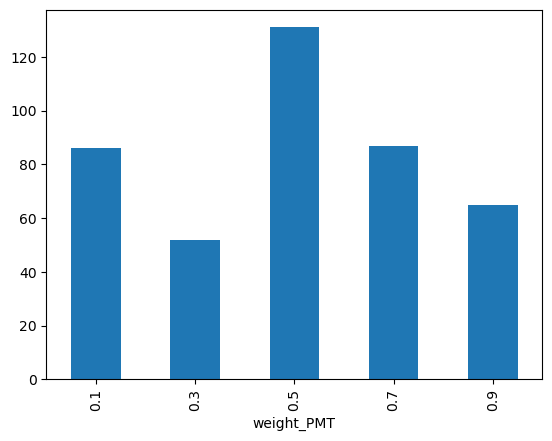

In [41]:
data_households_98_removed['weight_PMT'].value_counts(sort=False).sort_index().plot.bar()

In [42]:
data_households_98_removed.head()

,R05_worry,Q18_flood_exp,Q0_age,Q53_income_UK,Q4_home_size_UK,R03_perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implemented_DP,implemented_WP,Perc_probability,Level_Education,annual_income,savings_multiplier,house_size,savings,weight_PMT,weight_SN
3,0.00,0,35,5,6,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.0,83518.75,4.0,105.576208,334075.000,0.1,0.9
5,0.00,0,74,1,2,0.5,0.000000,0.000000,0.500000,0.500000,0.833333,0.916667,0.0,0.0,0.0,1.0,18149.30,0.5,18.587361,9074.650,0.3,0.7
6,0.00,0,56,2,3,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.0,0.0,2.0,20575.80,0.0,24.442379,0.000,0.1,0.9
7,0.00,0,70,5,6,0.0,0.833333,0.000000,0.333333,0.166667,0.500000,0.916667,0.0,0.0,0.0,2.0,83518.75,4.0,105.576208,334075.000,0.7,0.3
8,0.25,0,57,5,1,0.0,0.583333,0.333333,0.583333,0.666667,0.500000,0.750000,0.0,1.0,0.0,4.0,83518.75,1.5,10.687732,125278.125,0.5,0.5


#### Save dataframe for household agent generation

In [43]:
data_households_98_removed.to_csv('../../data/processed/household_data.csv')

### Make separate dataframes for socio-demograhics and PMT-related variables
The idea is to have to separate dataframes ie two separate sets of synthetic population from which we can draw.

In [44]:
HH_sociodemographics = data_households_98_removed[['Q0_age', 'Level_Education', 'Q53_income_UK', 'annual_income', 'savings', 'house_size']]
HH_sociodemographics = HH_sociodemographics.rename(columns={'Q0_age': 'age', 'Q53_income_UK': 'income_category'})
HH_PMTrelated = data_households_98_removed[['Perc_probability', 'R05_worry', 'Q18_flood_exp', 'R03_perc_damage',
                                            'self_efficacy_DP', 'self_efficacy_WP', 'resp_efficacy_DP', 'resp_efficacy_WP',
                                            'perc_cost_DP', 'perc_cost_WP', 'implemented_DP', 'implemented_WP', 'weight_SN', 'weight_PMT']]
HH_PMTrelated = HH_PMTrelated.rename(columns={'R05_worry': 'worry', 'Q18_flood_exp': 'flood_experience', 'R03_perc_damage': 'perc_damage'})

In [45]:
HH_sociodemographics.head()

,age,Level_Education,income_category,annual_income,savings,house_size
3,35,1.0,5,83518.75,334075.000,105.576208
5,74,1.0,1,18149.30,9074.650,18.587361
6,56,2.0,2,20575.80,0.000,24.442379
7,70,2.0,5,83518.75,334075.000,105.576208
8,57,4.0,5,83518.75,125278.125,10.687732


In [46]:
HH_PMTrelated['perc_risk'] = HH_PMTrelated['Perc_probability'] * HH_PMTrelated['perc_damage']

In [47]:
HH_PMTrelated.head()

,Perc_probability,worry,flood_experience,perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implemented_DP,implemented_WP,weight_SN,weight_PMT,perc_risk
3,0.0,0.00,0,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.9,0.1,0.0
5,0.0,0.00,0,0.5,0.000000,0.000000,0.500000,0.500000,0.833333,0.916667,0.0,0.0,0.7,0.3,0.0
6,0.0,0.00,0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.0,0.9,0.1,0.0
7,0.0,0.00,0,0.0,0.833333,0.000000,0.333333,0.166667,0.500000,0.916667,0.0,0.0,0.3,0.7,0.0
8,0.0,0.25,0,0.0,0.583333,0.333333,0.583333,0.666667,0.500000,0.750000,0.0,1.0,0.5,0.5,0.0


In [48]:
HH_PMTrelated.describe()

,Perc_probability,worry,flood_experience,perc_damage,self_efficacy_DP,self_efficacy_WP,resp_efficacy_DP,resp_efficacy_WP,perc_cost_DP,perc_cost_WP,implemented_DP,implemented_WP,weight_SN,weight_PMT,perc_risk
count,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,0.020404,0.126485,0.163895,0.254751,0.263658,0.208432,0.435669,0.429929,0.700515,0.797902,0.033254,0.078385,0.503325,0.496675,0.009070
std,0.119503,0.216587,0.370621,0.300260,0.298909,0.267424,0.269912,0.283191,0.238545,0.192746,0.179513,0.269096,0.265990,0.265990,0.063707
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.100000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.250000,0.500000,0.666667,0.000000,0.000000,0.300000,0.300000,0.000000
50%,0.000000,0.000000,0.000000,0.250000,0.166667,0.083333,0.500000,0.500000,0.666667,0.833333,0.000000,0.000000,0.500000,0.500000,0.000000
75%,0.002000,0.250000,0.000000,0.500000,0.500000,0.416667,0.583333,0.583333,1.000000,1.000000,0.000000,0.000000,0.700000,0.700000,0.000500
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.900000,0.900000,0.750000


In [49]:
HH_sociodemographics.describe()

,age,Level_Education,income_category,annual_income,savings,house_size
count,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,52.194774,2.921615,3.484561,49205.325891,129745.179810,61.927699
std,15.758900,0.859697,1.450082,26759.076711,124143.689529,37.028549
min,18.000000,1.000000,1.000000,18149.300000,0.000000,10.687732
25%,39.000000,2.000000,2.000000,20575.800000,0.000000,24.442379
50%,54.000000,3.000000,4.000000,44266.950000,88533.900000,86.431227
75%,65.000000,4.000000,5.000000,83518.750000,177067.800000,105.576208
max,89.000000,4.000000,5.000000,83518.750000,334075.000000,105.576208


In [48]:
HH_sociodemographics.to_csv('../../data/processed/Sociodemographics.csv')
HH_PMTrelated.to_csv('../../data/processed/PMT_variables.csv')

## Checking homophily possibilities 

In [43]:
grouped_sociodemographics = HH_sociodemographics.groupby(['Level_Education', 'income_category'])
grouped_sociodemographics.describe()

age                                     \
                                count       mean        std   min    25%   
Level_Education income_category                                            
1.0             1                 5.0  57.800000  15.865056  33.0  56.00   
                2                 2.0  70.500000   0.707107  70.0  70.25   
                3                 1.0  59.000000        NaN  59.0  59.00   
                4                 4.0  58.000000  15.383974  39.0  48.75   
                5                 2.0  48.000000  18.384776  35.0  41.50   
2.0             1                27.0  50.814815  15.236689  21.0  46.00   
                2                25.0  53.200000  16.610739  20.0  38.00   
                3                21.0  50.285714  15.595329  19.0  42.00   
                4                26.0  54.500000  14.656739  27.0  42.00   
                5                32.0  50.468750  18.919156  19.0  34.75   
3.0             1                17.0  51.000000  15.008331  24.0  39.00   
                2                20.0  55.650000  15.661804  27.0  47.50   
                3                30.0  52.966667  16.814369  18.0  38.00   
                4                31.0  52.935484  14.075831  25.0  41.50   
                5                52.0  47.365385  14.061530  23.0  33.00   
4.0             1                12.0  50.666667  14.008655  24.0  46.75   
                2                11.0  59.000000  16.056151  27.0  49.50   
                3                14.0  50.285714  16.273757  25.0  38.75   
                4                27.0  59.555556  15.438048  33.0  45.00   
                5                62.0  50.403226  16.296897  24.0  36.25   

                                                   annual_income           \
                                  50%    75%   max         count     mean   
Level_Education income_category                                             
1.0             1                57.0  69.00  74.0           5.0  17114.0   
                2                70.5  70.75  71.0           2.0  18944.0   
                3                59.0  59.00  59.0           1.0  24338.0   
                4                61.0  70.25  71.0           4.0  37357.0   
                5                48.0  54.50  61.0           2.0  68525.0   
2.0             1                55.0  61.00  79.0          27.0  17114.0   
                2                56.0  65.00  76.0          25.0  18944.0   
                3                52.0  58.00  80.0          21.0  24338.0   
                4                55.0  63.75  86.0          26.0  37357.0   
                5                54.5  63.00  86.0          32.0  68525.0   
3.0             1                55.0  62.00  77.0          17.0  17114.0   
                2                55.0  67.25  89.0          20.0  18944.0   
                3                53.5  67.75  77.0          30.0  24338.0   
                4                55.0  64.50  79.0          31.0  37357.0   
                5                46.5  58.25  72.0          52.0  68525.0   
4.0             1                50.0  60.00  72.0          12.0  17114.0   
                2                60.0  71.00  80.0          11.0  18944.0   
                3                49.5  64.50  75.0          14.0  24338.0   
                4                66.0  71.00  80.0          27.0  37357.0   
                5                49.5  63.75  80.0          62.0  68525.0   

                                                                          \
                                 std      min      25%      50%      75%   
Level_Education income_category                                            
1.0             1                0.0  17114.0  17114.0  17114.0  17114.0   
                2                0.0  18944.0  18944.0  18944.0  18944.0   
                3                NaN  24338.0  24338.0  24338.0  24338.0   
                4                0.0  37357.0  37357.0  3

In [44]:
valid_pairs = []
# Iterate through each group
for _, group in grouped_sociodemographics:
    if len(group) >= 2:  # Ensure there are at least 2 rows in the group
        # Sort by 'age' to easily check the difference
        group = group.sort_values(by='age')
        print(group)
        # Check for pairs where the age difference is <= 10
        for i in range(len(group) - 1):
            for j in range(i + 1, len(group)):
                if abs(group.iloc[i]['age'] - group.iloc[j]['age']) <= 10:
                    # Store the pair in sorted order to avoid duplicates
                    pair = tuple(sorted((group.index[i], group.index[j])))
                    if pair not in valid_pairs:  # Avoid adding duplicates
                         valid_pairs.append(pair)

     age  Level_Education  income_category  annual_income  savings  house_size
651   33              1.0                1        17114.0      0.0  114.684015
242   56              1.0                1        17114.0  68456.0  151.022305
350   57              1.0                1        17114.0      0.0  114.684015
502   69              1.0                1        17114.0      0.0   17.379182
5     74              1.0                1        17114.0   8557.0   17.379182
     age  Level_Education  income_category  annual_income  savings  house_size
571   70              1.0                2        18944.0      0.0   26.394052
125   71              1.0                2        18944.0      0.0  114.684015
     age  Level_Education  income_category  annual_income   savings  \
74    39              1.0                4        37357.0   18678.5   
370   52              1.0                4        37357.0       0.0   
108   70              1.0                4        37357.0  149428.0   
356  

In [45]:
len(valid_pairs)

2347

In [46]:
valid_pairs

[(242, 350),
 (5, 502),
 (125, 571),
 (108, 356),
 (555, 703),
 (555, 622),
 (434, 555),
 (622, 703),
 (434, 703),
 (434, 622),
 (434, 676),
 (676, 741),
 (733, 741),
 (646, 741),
 (646, 733),
 (679, 733),
 (401, 733),
 (402, 733),
 (244, 733),
 (238, 733),
 (695, 733),
 (597, 733),
 (458, 733),
 (646, 679),
 (401, 646),
 (402, 646),
 (244, 646),
 (238, 646),
 (646, 695),
 (597, 646),
 (458, 646),
 (401, 679),
 (402, 679),
 (244, 679),
 (238, 679),
 (679, 695),
 (597, 679),
 (458, 679),
 (454, 679),
 (361, 679),
 (576, 679),
 (401, 402),
 (244, 401),
 (238, 401),
 (401, 695),
 (401, 597),
 (401, 458),
 (401, 454),
 (361, 401),
 (401, 576),
 (401, 411),
 (244, 402),
 (238, 402),
 (402, 695),
 (402, 597),
 (402, 458),
 (402, 454),
 (361, 402),
 (402, 576),
 (402, 411),
 (238, 244),
 (244, 695),
 (244, 597),
 (244, 458),
 (244, 454),
 (244, 361),
 (244, 576),
 (244, 411),
 (238, 695),
 (238, 597),
 (238, 458),
 (238, 454),
 (238, 361),
 (238, 576),
 (238, 411),
 (597, 695),
 (458, 695),
 

In [47]:
selected_pair = random.choice(valid_pairs)
selected_pair[0]

559

In [48]:
HH_sociodemographics.loc[selected_pair[0], 'annual_income']

68525.0